In [1]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/casting_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")
print("Extracted to:", extract_path)

# Show extracted folder structure
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

Extraction complete.
Extracted to: /content/casting_dataset
casting_dataset/
    casting_512x512/
        casting_512x512/
            def_front/
            ok_front/
    casting_data/
        casting_data/
            train/
                def_front/
                ok_front/
            test/
                def_front/
                ok_front/


In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 9.5 MB/s eta 0:00:00


In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [7]:
dataset = "/content/casting_dataset/casting_data/casting_data"

train_path = os.path.join(dataset, "train")
test_path = os.path.join(dataset, "test")

train_defective = os.path.join(train_path, "def_front")
train_ok = os.path.join(train_path, "ok_front")

test_defective = os.path.join(test_path, "def_front")
test_ok = os.path.join(test_path, "ok_front")

print("Train path:", train_path)
print("Test path:", test_path)

print("\nTraining defective images:", len(os.listdir(train_defective)))
print("Training OK images:", len(os.listdir(train_ok)))

print("Testing defective images:", len(os.listdir(test_defective)))
print("Testing OK images:", len(os.listdir(test_ok)))

Train path: /content/casting_dataset/casting_data/casting_data/train
Test path: /content/casting_dataset/casting_data/casting_data/test

Training defective images: 3758
Training OK images: 2875
Testing defective images: 453
Testing OK images: 262


In [8]:
from sklearn.model_selection import train_test_split
import shutil

split_root = "/content/casting_split"

train_split_path = os.path.join(split_root, "train")
val_split_path = os.path.join(split_root, "val")

classes = ["def_front", "ok_front"]

# Remove old split folder if this cell is rerun
if os.path.exists(split_root):
    shutil.rmtree(split_root)

# Create train/val class folders
for split_path in [train_split_path, val_split_path]:
    for class_name in classes:
        os.makedirs(
            os.path.join(split_path, class_name),
            exist_ok=True
        )

# Split each class separately so class proportions stay similar
for class_name in classes:

    source_dir = os.path.join(train_path, class_name)

    image_files = [
        f for f in os.listdir(source_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    train_files, val_files = train_test_split(
        image_files,
        test_size=0.20,
        random_state=42,
        shuffle=True
    )

    # Copy training images
    for file_name in train_files:
        shutil.copy2(
            os.path.join(source_dir, file_name),
            os.path.join(train_split_path, class_name, file_name)
        )

    # Copy validation images
    for file_name in val_files:
        shutil.copy2(
            os.path.join(source_dir, file_name),
            os.path.join(val_split_path, class_name, file_name)
        )

print("Train/validation split completed.")

for class_name in classes:
    print(
        class_name,
        "| Train:",
        len(os.listdir(os.path.join(train_split_path, class_name))),
        "| Validation:",
        len(os.listdir(os.path.join(val_split_path, class_name)))
    )

Train/validation split completed.
def_front | Train: 3006 | Validation: 752
ok_front | Train: 2300 | Validation: 575


In [9]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

IMG_SIZE = 300
BATCH_SIZE = 32

# Mild augmentation only for training
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor()
])

# No augmentation for validation/test
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# Datasets
train_dataset = ImageFolder(
    root=train_split_path,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=val_split_path,
    transform=eval_transform
)

test_dataset = ImageFolder(
    root=test_path,
    transform=eval_transform
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("\nTraining samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Classes: ['def_front', 'ok_front']
Class mapping: {'def_front': 0, 'ok_front': 1}

Training samples: 5306
Validation samples: 1327
Testing samples: 715


In [10]:
from ultralytics import YOLO

# Load pretrained YOLO11n classification model
yolo = YOLO("yolo11n-cls.pt")

model = yolo.model.to(device)

print("Model loaded successfully.")
print("\nFinal classification head:")
print(model.model[-1])

Model loaded successfully.

Final classification head:
Classify(
  (conv): Conv(
    (conv): Conv2d(256, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.0, inplace=True)
  (linear): Linear(in_features=1280, out_features=1000, bias=True)
)


In [11]:
# Freeze the entire pretrained YOLO model
for param in model.parameters():
    param.requires_grad = False

# Replace only the final classification layer
in_features = model.model[-1].linear.in_features

model.model[-1].linear = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)

# Move model to GPU
model = model.to(device)

print("Modified classification head:")
print(model.model[-1])

# Check how many parameters will actually be trained
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("\nTrainable parameters:", trainable_params)

Modified classification head:
Classify(
  (conv): Conv(
    (conv): Conv2d(256, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.0, inplace=True)
  (linear): Sequential(
    (0): Linear(in_features=1280, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

Trainable parameters: 164226


In [12]:
# Get training labels
train_labels = [label for _, label in train_dataset.samples]

# Count samples per class
class_counts = np.bincount(train_labels)

# Compute simple inverse-frequency class weights
class_weights = len(train_labels) / (2 * class_counts)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

# Loss function
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer - only train the modified classification head
optimizer = torch.optim.Adam(
    model.model[-1].linear.parameters(),
    lr=0.001
)

print("\nLoss function and optimizer ready.")

Class counts: [3006 2300]
Class weights: tensor([0.8826, 1.1535], device='cuda:0')

Loss function and optimizer ready.


In [14]:
EPOCHS = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

best_model_path = "/content/best_yolo11n_casting.pth"


for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # In training mode YOLO returns logits directly
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predicted = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_loss = running_loss / total
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # YOLO classification returns:
            # (probabilities, logits) in evaluation mode
            if isinstance(outputs, tuple):
                logits = outputs[1]
            else:
                logits = outputs

            loss = criterion(logits, labels)

            running_val_loss += loss.item() * images.size(0)

            predicted = torch.argmax(logits, dim=1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()


    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    # =========================
    # RESULTS
    # =========================
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f}"
    )


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved.")

Epoch [1/30] | Train Loss: 0.1560 | Train Acc: 0.9403 | Val Loss: 0.0787 | Val Acc: 0.9721
Best model saved.
Epoch [2/30] | Train Loss: 0.1528 | Train Acc: 0.9406 | Val Loss: 0.0620 | Val Acc: 0.9797
Best model saved.
Epoch [3/30] | Train Loss: 0.0940 | Train Acc: 0.9655 | Val Loss: 0.0557 | Val Acc: 0.9842
Best model saved.
Epoch [4/30] | Train Loss: 0.0948 | Train Acc: 0.9670 | Val Loss: 0.0469 | Val Acc: 0.9849
Best model saved.
Epoch [5/30] | Train Loss: 0.0976 | Train Acc: 0.9621 | Val Loss: 0.0534 | Val Acc: 0.9842
Epoch [6/30] | Train Loss: 0.0745 | Train Acc: 0.9719 | Val Loss: 0.0438 | Val Acc: 0.9842
Best model saved.
Epoch [7/30] | Train Loss: 0.0762 | Train Acc: 0.9738 | Val Loss: 0.0406 | Val Acc: 0.9879
Best model saved.
Epoch [8/30] | Train Loss: 0.0760 | Train Acc: 0.9729 | Val Loss: 0.0424 | Val Acc: 0.9834
Epoch [9/30] | Train Loss: 0.0611 | Train Acc: 0.9787 | Val Loss: 0.0564 | Val Acc: 0.9789
Epoch [10/30] | Train Loss: 0.0600 | Train Acc: 0.9787 | Val Loss: 0.0315

In [15]:
# Load the best model weights saved during training
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [16]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # YOLO classification returns tuple in eval mode
        if isinstance(outputs, tuple):
            logits = outputs[1]
        else:
            logits = outputs

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 99.58%


Confusion Matrix:
[[451   2]
 [  1 261]]


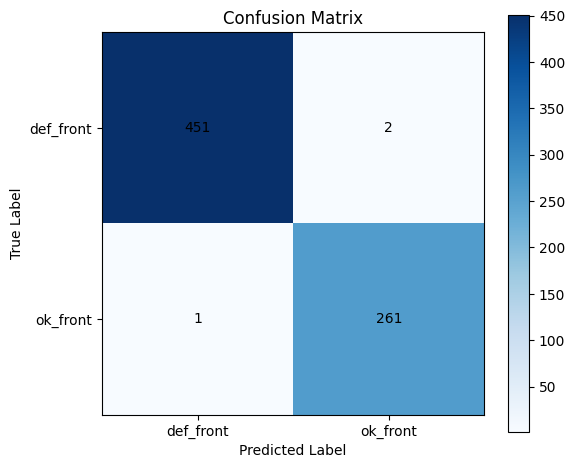


Classification Report:

              precision    recall  f1-score   support

   def_front     0.9978    0.9956    0.9967       453
    ok_front     0.9924    0.9962    0.9943       262

    accuracy                         0.9958       715
   macro avg     0.9951    0.9959    0.9955       715
weighted avg     0.9958    0.9958    0.9958       715



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["def_front", "ok_front"])
plt.yticks([0, 1], ["def_front", "ok_front"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["def_front", "ok_front"],
        digits=4
    )
)

In [25]:
full_model_path = "/content/complete_defect_classifier.pth"

torch.save(
    model,
    full_model_path
)

print("Complete trained model saved at:")
print(full_model_path)

Complete trained model saved at:
/content/complete_defect_classifier.pth


In [26]:
from google.colab import files

files.download("/content/complete_defect_classifier.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

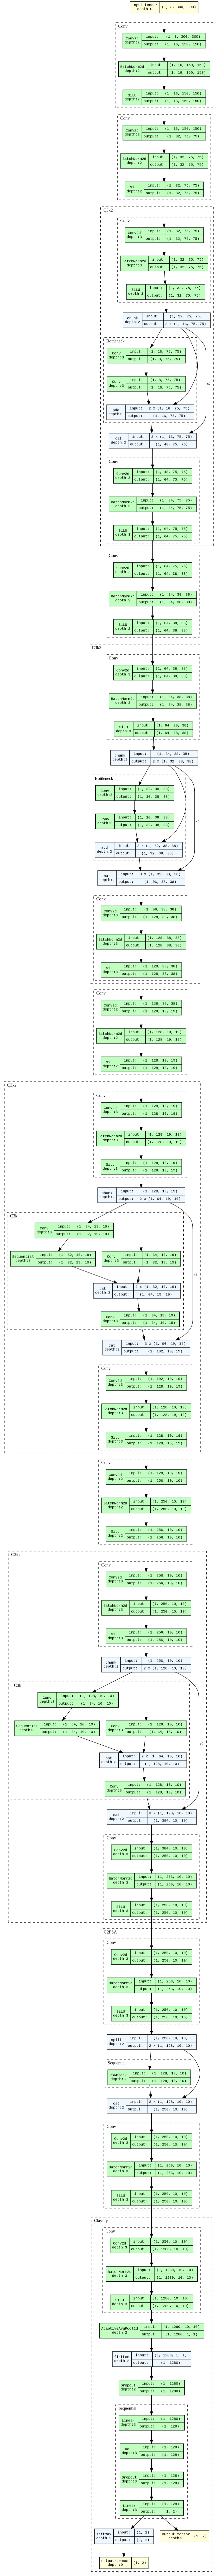

In [28]:
!pip install -q torchview graphviz

from torchview import draw_graph
from IPython.display import Image, display

# Keep model on the current device
model = model.to(device)
model.eval()

# Create architecture visualization
model_graph = draw_graph(
    model,
    input_size=(1, 3, 300, 300),
    device=device,
    expand_nested=True,
    graph_dir="TB",
    save_graph=True,
    filename="/content/modified_yolo11n_architecture"
)

# Display architecture diagram
display(
    Image(
        filename="/content/modified_yolo11n_architecture.png"
    )
)

In [23]:
# Find misclassified samples
misclassified = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        if isinstance(outputs, tuple):
            logits = outputs[1]
        else:
            logits = outputs

        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        for i in range(len(labels)):

            if predictions[i] != labels[i]:

                confidence = probabilities[
                    i,
                    predictions[i]
                ].item()

                misclassified.append({
                    "image": images[i].cpu(),
                    "actual": labels[i].item(),
                    "predicted": predictions[i].item(),
                    "confidence": confidence
                })

print("Total misclassified images:", len(misclassified))

Total misclassified images: 3


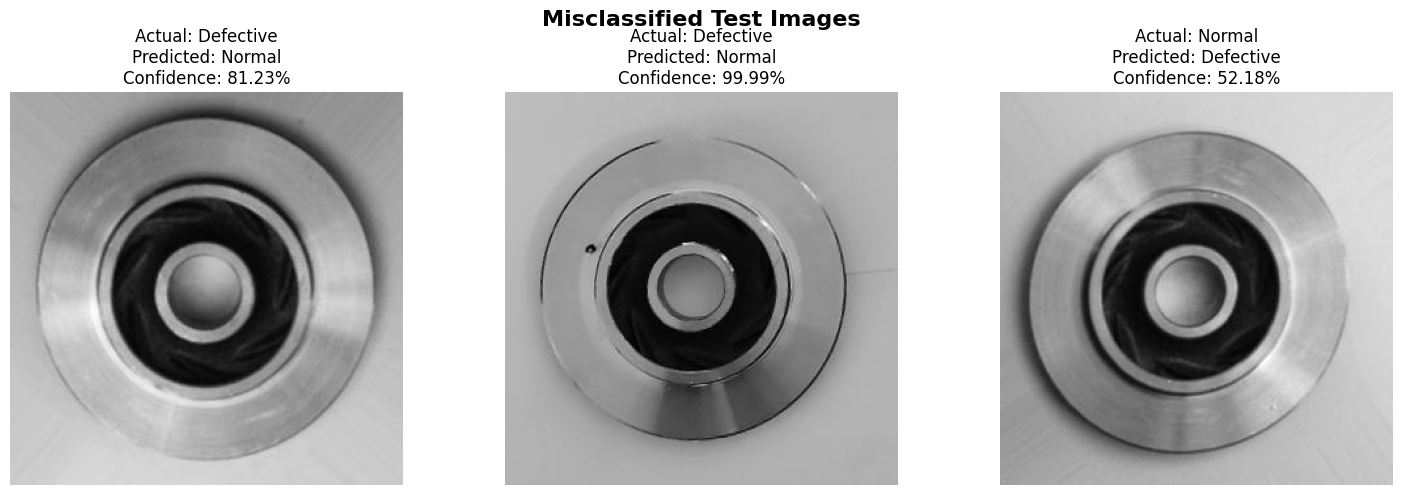

In [24]:
class_names = {
    0: "Defective",
    1: "Normal"
}

fig, axes = plt.subplots(
    1,
    len(misclassified),
    figsize=(15, 5)
)

if len(misclassified) == 1:
    axes = [axes]

for i, item in enumerate(misclassified):

    image = item["image"].permute(1, 2, 0).numpy()

    axes[i].imshow(image)
    axes[i].axis("off")

    axes[i].set_title(
        f"Actual: {class_names[item['actual']]}\n"
        f"Predicted: {class_names[item['predicted']]}\n"
        f"Confidence: {item['confidence']*100:.2f}%"
    )

plt.suptitle(
    "Misclassified Test Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()